# Filling in Gaps in Observational Data
Caitlin R. R. Turner, January 2026

This notebook demonstrates GaugePredict's capability to estimate discharge during periods of missing data when sensors are down using only upstream predictor gauge information. During June 2023, the primary discharge gauge at Baton Rouge was down, leaving a gap in observations. The Baton Rouge gauge is a high priority gauge, so the U.S. Geological survey supplements the data. Not all gauges have this workflow. Downed gauges with periods of missing data is a struggle when builing physical and numerical models.

To address this issue, the GaugePredict model was trained to forecast discharge without reliance on the target site's measurements during the missing period, making it valuable for filling these observational gaps. The visualization compares model predictions against USGS calculated discharge as a reference proxy.

### Import Necessary Dependencies

Load all required Python libraries for data handling, visualization, and GaugePredict utilities.

In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import cmocean

from GaugePredict.downloader import load_target

## Configuration

Identify previously run GaugePredict model. Model outputs are in `examples/results/`

In [ ]:

# Configuration
target_site = "07374000"
run_name = "final_br_fillin"
target_variable = "discharge"
horizons = [1]

label_site = "Mississippi River at Baton Rouge (USGS)"
label_obs = "Measured (USGS)"
label_pred = "Forecasted (GaugePredict)"
label_usgs = "Calculated (USGS)"

usgs_start = "2023-06-14"
usgs_end = "2023-06-26"

roll_window_days = 1
fig_w, fig_h = 4.9, 1.5
dpi = 600
save_fig = True
y_scale = 1.0e4  # 10^4 scaling

# Paths (notebook-aware)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent.parent
examples_dir = project_root / "examples"
results_root = examples_dir / "results" / f"{target_site}_{run_name}"
fig_path = results_root / "fig_test_timeseries_with_usgs_provisional.png"

### Define Helper Functions

Define utility functions for directory navigation and distance calculations used in USGS data processing.

In [9]:
# Helper functions
def _hdir(root, h):
    """Get horizon-specific subdirectory."""
    return Path(root) / f"H{int(h):02d}"

def _logdist(a, b):
    """Compute log-distance between two positive values."""
    if not np.isfinite(a) or not np.isfinite(b) or a <= 0 or b <= 0:
        return np.inf
    return abs(np.log10(a) - np.log10(b))

### Load Forecast and Observational Data

Load saved GaugePredict forecasts for the target site and prepare baseline observational discharge data from model results.

In [10]:
# Load forecast predictions
runs = {}
for h in horizons:
    d = _hdir(results_root, h)
    pred_fp = d / "predictions.csv"
    metr_fp = d / "metrics.json"
    
    df = pd.read_csv(pred_fp)
    dates = pd.to_datetime(df["date"], utc=True).dt.tz_convert(None)
    
    runs[int(h)] = dict(
        dates=dates,
        y_true=df["y_true"].astype(float).to_numpy(),
        y_pred=df["y_pred"].astype(float).to_numpy(),
        metr=json.load(open(metr_fp, "r", encoding="utf-8")) if metr_fp.exists() else None,
    )

hs = sorted(runs.keys())
print(f"Loaded {len(hs)} horizon(s): {hs}")

Loaded 1 horizon(s): [1]


### Prepare Observed Data

Find the common date range across all horizons and extract the observed discharge time series. Apply optional smoothing over a rolling window.

In [11]:
# Align dates across horizons
date_index = None
for h in hs:
    d = runs[h]["dates"]
    date_index = d if date_index is None else date_index.intersection(d)

# Extract observed data
base_h = max(hs)
y_true_base = pd.Series(runs[base_h]["y_true"], index=runs[base_h]["dates"]).reindex(date_index).to_numpy()
y_obs = pd.Series(y_true_base, index=date_index)

if roll_window_days and int(roll_window_days) > 1:
    y_obs_plot = y_obs.rolling(f"{int(roll_window_days)}D", center=True).mean()
else:
    y_obs_plot = y_obs

y_obs_plot = y_obs_plot / y_scale
print(f"Date range: {date_index.min()} to {date_index.max()}")

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


### Load USGS Reference Data

Fetch USGS calculated discharge values from the NWIS service and auto-scale them to match the observed data magnitude during the validation period.

In [12]:
# Load and process USGS data
usgs_s = None
try:
    overlay_index = pd.date_range(start=usgs_start, end=usgs_end, freq="D")
    usgs_ts = load_target(
        target_site=target_site,
        full_index=overlay_index,
        start_date=usgs_start,
        end_date=usgs_end,
        parameter_code="00060",
        to_units="metric",
        tz="UTC",
        parameter_kind="discharge",
    )
    
    y_ref_win = y_obs_plot.loc[pd.to_datetime(usgs_start):pd.to_datetime(usgs_end)]
    ref_med = float(np.nanmedian(np.abs(y_ref_win.to_numpy(dtype=float))))
    
    usgs_m3s = usgs_ts.astype(float)
    usgs_m3s_1e4 = usgs_m3s / 1.0e4
    usgs_cfs = usgs_m3s / 0.0283168466
    usgs_cfs_1e4 = usgs_cfs / 1.0e4
    
    cands = {
        "m3s": usgs_m3s / y_scale,
        "m3s/1e4": usgs_m3s_1e4 / y_scale,
        "cfs": usgs_cfs / y_scale,
        "cfs/1e4": usgs_cfs_1e4 / y_scale,
    }
    
    best_key = min(
        cands.keys(),
        key=lambda k: _logdist(
            ref_med,
            float(np.nanmedian(np.abs(cands[k].to_numpy(dtype=float))))
        ),
    )
    
    usgs_plot = cands[best_key]
    usgs_x = usgs_plot.index.tz_convert("UTC").tz_localize(None)
    usgs_s = pd.Series(usgs_plot.to_numpy(dtype=float), index=usgs_x)
    usgs_s = usgs_s.reindex(date_index).loc[pd.to_datetime(usgs_start):pd.to_datetime(usgs_end)]
    
    if roll_window_days and int(roll_window_days) > 1:
        usgs_s = usgs_s.rolling(f"{int(roll_window_days)}D", center=True).mean()
    
    print(f"USGS data loaded (scale: {best_key})")
    
except Exception as e:
    print(f"Could not load USGS data: {e}")
    usgs_s = None

USGS data loaded (scale: m3s)


## Create Forecast Comparison Figure

The figure displays three time series: measured USGS discharge (gray), USGS calculated discharge (blue), and GaugePredict forecast (dashed line). The validation period spans June 14–26, 2023. Values are scaled by $10^{4}$ for visualization clarity.

I personally like customizing my plots, so here is an example of what I do. 

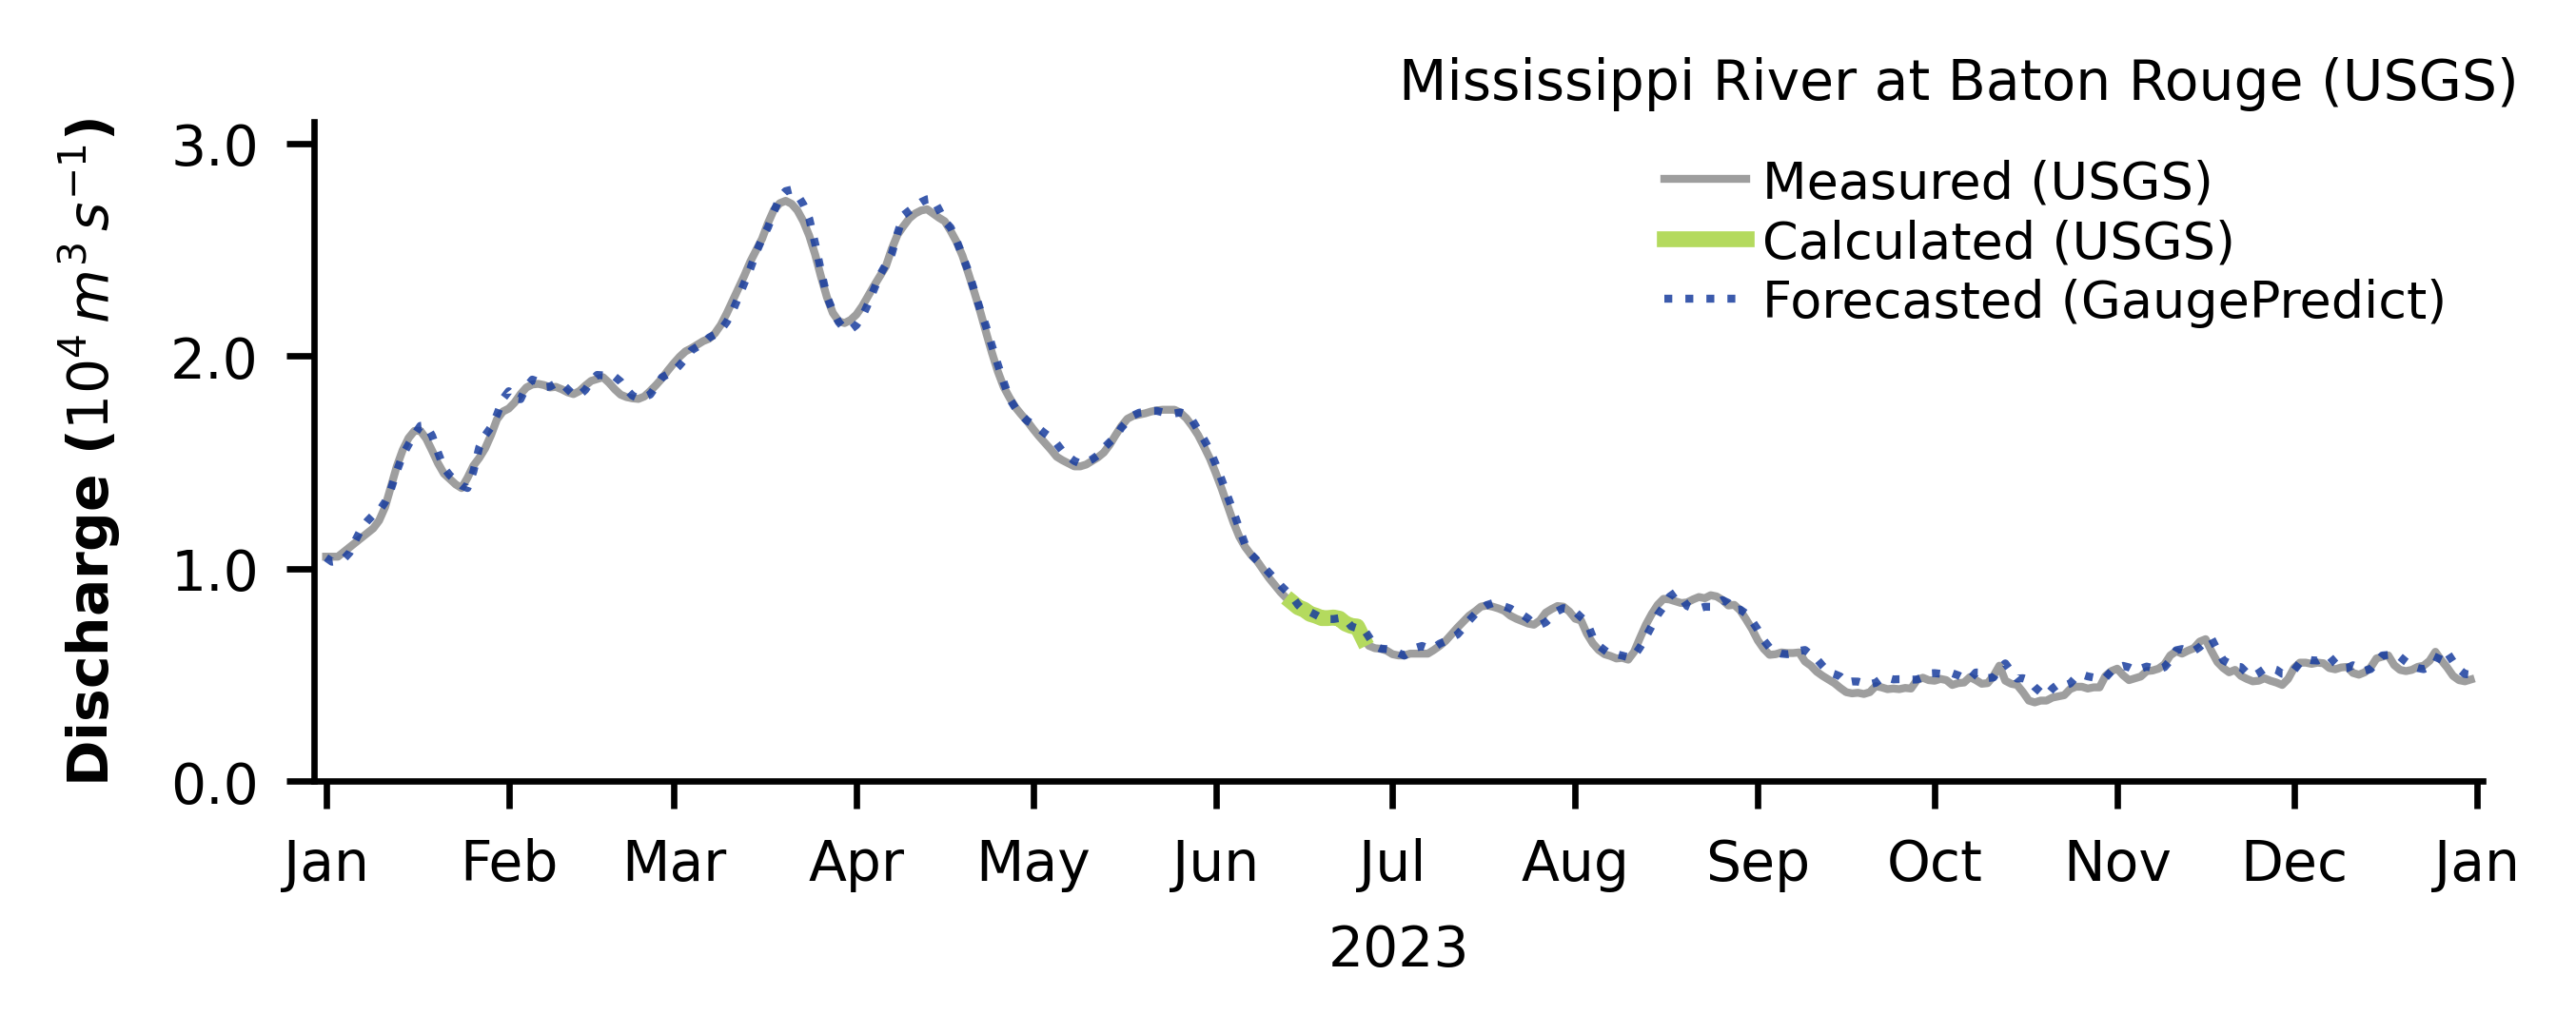

In [13]:


fig_w, fig_h = 4.9, 1.5
dpi = 600
save_fig = True


# Setup colors and line styles for visualization
cmap = cmocean.cm.haline
den = max(1, len(hs) - 1)
linestyles_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]

colors_h = {}
linestyles_h = {}
for idx, h in enumerate(hs):
    frac = 0.15 + (0.90 - 0.15) * (idx / den)
    colors_h[h] = cmap(frac)
    linestyles_h[h] = linestyles_cycle[idx % len(linestyles_cycle)]


# Create plot
fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

# Measured observations
ax.plot(y_obs_plot.index, y_obs_plot.to_numpy(), lw=1.0, alpha=0.95, color="0.6", label=label_obs)

# USGS calculated data if available
if usgs_s is not None and np.isfinite(usgs_s.to_numpy(dtype=float)).any():
    ax.plot(usgs_s.index, usgs_s.to_numpy(), color=cmocean.cm.haline(0.85), lw=2, alpha=1.0, linestyle="-", label=label_usgs)

# Forecasts
first_forecast = True
for h in hs:
    y_pred = pd.Series(runs[h]["y_pred"], index=runs[h]["dates"]).reindex(date_index)
    if roll_window_days and int(roll_window_days) > 1:
        y_pred_plot = y_pred.rolling(f"{int(roll_window_days)}D", center=True).mean()
    else:
        y_pred_plot = y_pred
    
    y_pred_plot = y_pred_plot / y_scale
    ax.plot(y_pred_plot.index, y_pred_plot.to_numpy(), lw=1.0, color=cmocean.cm.haline(0.15), alpha=0.85, linestyle=":", label=label_pred if first_forecast else None)
    first_forecast = False

# Set limits and formatting
start_pad = pd.to_datetime(date_index.min()) - pd.Timedelta(days=2)
end_pad = pd.to_datetime(date_index.max()) + pd.Timedelta(days=2)
ax.set_xlim(start_pad, end_pad)
ax.set_ylim([0, 31000 / y_scale])

ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

ax.set_ylabel(r"Discharge ($10^{4}\, m^{3}\, s^{-1}$)", fontsize=7, fontweight="bold", labelpad=6)
ax.set_xlabel("2023", fontsize=7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.grid(False)

ax.text(0.5, 1.1, label_site, transform=ax.transAxes, ha="left", va="top", fontsize=7, zorder=10)

ax.legend(frameon=False, fontsize=6.5, ncol=1, handlelength=1.6, borderpad=0.2, labelspacing=0.2, handletextpad=0.3, loc="upper right")

# Axes Splines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Save figure
if save_fig:
    results_root.mkdir(parents=True, exist_ok=True)
    fig.savefig(fig_path, dpi=dpi, bbox_inches="tight")
    #print(f"Saved: {fig_path}")

plt.show()

If you have any questions or need help with implementation to your model, please do not hesitate to contact Caitlin R. R. Turner at cturn65@lsu.edu

## Acknowledgments

Research reported in this publication was supported by the US Department of Defense and Army Engineer Research and Development Center (ERDC) under Contract No. W912HZ2220005, the Gulf Research Program of the National Academies of Sciences, Engineering, and Medicine under award number SCON-10000883, and the NSF through Open Earthscape (Collaborative Research: Frameworks: OpenEarthscape, Transformative Cyberinfrastructure for Modeling and Simulation in the Earth-Surface Science Communities) award No. 2104102.